# Bài tập 2 — Đặc trưng góc & Phân vùng ảnh

**Môn:** Thị giác máy tính (121036) — Khoa CNTT, Trường ĐH Giao thông Vận tải TP.HCM

| | Điền vào |
|---|---|
| Họ tên | |
| MSSV | |
| Lớp | |
| Ngày nộp | |

---

## Cấu trúc

| Phần | Kinh điển | Biến thể | Điểm |
|---|---|---|---|
| **A** (Chương 3) | Harris corner detector | **A1** — Harris–Laplace<br>**A2** — Adaptive non-maximal suppression | 50 |
| **B** (Chương 4) | Region Growing | Seeded Region Growing (SRG) | 50 |

**A1 và A2 là hai biến thể độc lập.** Chúng sửa hai khiếm khuyết khác nhau của Harris và **không được ghép lại với nhau**. Mỗi biến thể so sánh trực tiếp với Harris cổ điển:

- **A1** chạy trên tháp tỉ lệ, so với Harris cổ điển một tỉ lệ.
- **A2** chạy trên tập điểm của Harris cổ điển một tỉ lệ, thay cho bước "lấy N điểm mạnh nhất".

Chi tiết công thức: `tailieu_bosung_bt2.pdf`.

---
## Chính sách sử dụng AI

| Loại cell | AI | |
|---|---|---|
| `Cài đặt — KHÔNG dùng AI` | ❌ | Kể cả nhờ AI sửa lỗi, tối ưu, hay viết lại |
| `Thí nghiệm — ĐƯỢC dùng AI` | ✅ | Nhưng **ý tưởng thí nghiệm phải là của bạn** |

Mỗi cell code có dùng AI phải có một cell markdown ngay phía trên, chép **nguyên văn** prompt. Dùng AI mà không khai báo ⇒ **0 điểm toàn bài**.

### Mẫu khai báo (copy khi cần)

```
> **KHAI BÁO AI**
> - Công cụ:
> - Mục đích:
> - Prompt nguyên văn:
>   (dán nguyên văn ở đây)
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☐
```

### Thư viện

| Luôn được phép | Có điều kiện | Không dùng trong phần cài đặt |
|---|---|---|
| `numpy`, `matplotlib`, `math`, `time` | `scipy.ndimage.gaussian_filter` | `cv2.cornerHarris` |
| | `heapq` (cho SRG) | `cv2.goodFeaturesToTrack` |
| | `cv2.imread/cvtColor/resize` | `skimage.feature.corner_*` |
| | `scipy.ndimage.label` (phần phân tích) | `skimage.segmentation.*`, `cv2.watershed` |

Ở **phần thí nghiệm**, được dùng hàm dựng sẵn để đối chiếu kết quả của mình.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import heapq, time
import random

np.random.seed(0)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["image.cmap"] = "gray"
print("numpy", np.__version__)

numpy 2.4.6


---
## Hàm hỗ trợ (cho sẵn — không cần sửa)

`grid_occupancy` và `mean_nn_distance` đo phân bố không gian của một tập điểm; dùng chúng để biến so sánh trực quan thành con số.

In [2]:
def show_grid(images, titles=None, ncols=None, cmap="gray", figsize=None, suptitle=None):
    """Hiển thị một danh sách ảnh trên lưới."""
    n = len(images)
    ncols = ncols or min(n, 4)
    nrows = (n + ncols - 1) // ncols
    figsize = figsize or (3.2 * ncols, 3.2 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            ax.imshow(images[i], cmap=cmap)
            if titles is not None:
                ax.set_title(titles[i], fontsize=9)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=11)
    plt.tight_layout()
    plt.show()


def show_points(img, points, ax=None, color="red", size=18, scale_circles=False, title=None):
    """Chồng điểm đặc trưng lên ảnh.

    points : mảng (N,2) (row, col), (N,3) (row, col, response),
             hoặc (N,4) (row, col, sigma, response).
    scale_circles : nếu True và points là (N,4), vẽ vòng tròn bán kính 3*sigma.
    """
    points = np.atleast_2d(np.asarray(points, dtype=float))
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img, cmap="gray")
    if points.size:
        ax.scatter(points[:, 1], points[:, 0], s=size, c=color,
                   marker="+", linewidths=1.0)
        if scale_circles and points.shape[1] >= 4:
            for r, c, s in points[:, :3]:
                ax.add_patch(plt.Circle((c, r), 3 * s, fill=False,
                                        color=color, lw=0.5, alpha=0.5))
    ax.set_title(title or f"{len(points)} diem", fontsize=9)
    ax.axis("off")
    if own:
        plt.tight_layout(); plt.show()


def show_labels(labels, title=None, ax=None):
    """Ảnh nhãn với bảng màu rời rạc; nhãn -1 hiện màu đen."""
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    disp = labels.astype(float).copy()
    disp[labels < 0] = np.nan
    cmap = plt.get_cmap("tab20").copy()
    cmap.set_bad(color="black")
    ax.imshow(disp, cmap=cmap, interpolation="nearest")
    ax.set_title(title or "labels", fontsize=9)
    ax.axis("off")
    if own:
        plt.tight_layout(); plt.show()


def grid_occupancy(points, img_shape, cells=8):
    """Tỉ lệ ô lưới (cells x cells) chứa ít nhất một điểm.

    Đo ĐỘ PHỦ của tập điểm: 1.0 = phủ khắp ảnh, giá trị nhỏ = điểm dồn cụm.
    """
    points = np.atleast_2d(np.asarray(points, dtype=float))
    if points.size == 0:
        return 0.0
    h, w = img_shape
    ri = np.clip((points[:, 0] / h * cells).astype(int), 0, cells - 1)
    ci = np.clip((points[:, 1] / w * cells).astype(int), 0, cells - 1)
    occupied = np.zeros((cells, cells), dtype=bool)
    occupied[ri, ci] = True
    return float(occupied.mean())


def mean_nn_distance(points):
    """Khoảng cách trung bình tới láng giềng gần nhất trong tập điểm.

    Đo độ THƯA: giá trị lớn = điểm trải rộng. Nhìn phân bố từ góc khác
    với grid_occupancy.
    """
    p = np.atleast_2d(np.asarray(points, dtype=float))[:, :2]
    if len(p) < 2:
        return float("nan")
    d = np.linalg.norm(p[:, None, :] - p[None, :, :], axis=-1)
    np.fill_diagonal(d, np.inf)
    return float(d.min(axis=1).mean())


def make_checkerboard(n=8, square=24, blur=0.8):
    """Ảnh bàn cờ n x n ô, mỗi ô 'square' px."""
    base = np.indices((n, n)).sum(axis=0) % 2
    img = np.kron(base, np.ones((square, square), dtype=float))
    if blur > 0:
        img = gaussian_filter(img, blur)
    return img


def rotate_image(img, degrees):
    """Quay ảnh quanh tâm bằng nội suy song tuyến."""
    h, w = img.shape
    th = np.deg2rad(degrees)
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    yy, xx = np.indices((h, w), dtype=float)
    ys, xs = yy - cy, xx - cx
    src_y = cy + ys * np.cos(th) + xs * np.sin(th)
    src_x = cx - ys * np.sin(th) + xs * np.cos(th)
    y0 = np.floor(src_y).astype(int); x0 = np.floor(src_x).astype(int)
    fy = src_y - y0; fx = src_x - x0
    out = np.zeros_like(img)
    ok = (y0 >= 0) & (y0 < h - 1) & (x0 >= 0) & (x0 < w - 1)
    y0c, x0c = np.clip(y0, 0, h - 2), np.clip(x0, 0, w - 2)
    v = ((1 - fy) * (1 - fx) * img[y0c, x0c] + (1 - fy) * fx * img[y0c, x0c + 1]
         + fy * (1 - fx) * img[y0c + 1, x0c] + fy * fx * img[y0c + 1, x0c + 1])
    out[ok] = v[ok]
    return out

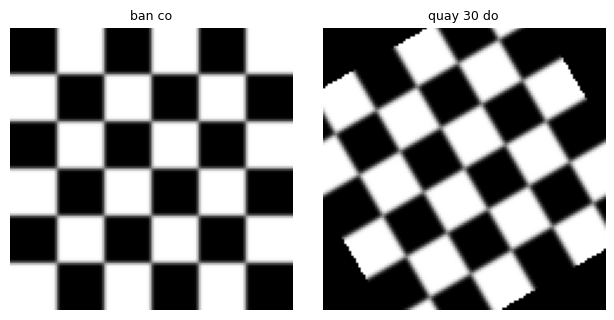

don cum : occupancy=0.14  mean_nn=2.8
trai deu: occupancy=0.47  mean_nn=9.1


In [3]:
# Kiểm tra nhanh các hàm hỗ trợ
cb = make_checkerboard(6, 20)
show_grid([cb, rotate_image(cb, 30)], ["ban co", "quay 30 do"], ncols=2)

clustered = np.random.rand(40, 2) * [30, 30] + [10, 10]
spread    = np.random.rand(40, 2) * [110, 110] + [5, 5]
print(f"don cum : occupancy={grid_occupancy(clustered, cb.shape):.2f}  "
      f"mean_nn={mean_nn_distance(clustered):.1f}")
print(f"trai deu: occupancy={grid_occupancy(spread, cb.shape):.2f}  "
      f"mean_nn={mean_nn_distance(spread):.1f}")

---
---
# PHẦN A — Harris và hai biến thể độc lập

Harris có hai hạn chế **riêng biệt**:

1. **Không bất biến tỉ lệ** — cùng một góc ở hai kích thước cho hai đáp ứng khác nhau. → **A1: Harris–Laplace** thêm trục tỉ lệ và lọc bằng cực trị LoG theo trục đó.
2. **Phân bố điểm không đều** — lấy N điểm mạnh nhất thì chúng dồn vào vùng tương phản cao. → **A2: ANMS** thay tiêu chí chọn bằng bán kính mà tại đó điểm thôi là cực đại.

Hạn chế 2 xuất hiện ngay cả khi mọi cấu trúc trong ảnh có cùng một tỉ lệ. Đó là lý do hai biến thể được đánh giá riêng.

## A.1 — Cài đặt — **KHÔNG dùng AI**

### Nền chung

In [4]:
def gaussian_blur(img, sigma):
    """Làm mờ Gauss. Được phép gọi scipy.ndimage.gaussian_filter."""
    raise NotImplementedError


def structure_tensor(img, sigma_i, sigma_d):
    """Ma trận mô-men bậc hai — công thức (1) trong tài liệu:

        M = sigma_d^2 * G(sigma_i) * [[Lx^2, LxLy], [LxLy, Ly^2]]

    với Lx = d/dx [ G(sigma_d) * I ].

    sigma_d : độ mờ trước khi lấy đạo hàm (differentiation scale)
    sigma_i : bán kính cửa sổ lấy trung bình các tích đạo hàm (integration scale)

    Hệ số sigma_d**2 là chuẩn hoá theo tỉ lệ (Lindeberg 1998), làm cho đáp ứng
    ở các tỉ lệ khác nhau so sánh được với nhau.

    -> (Mxx, Mxy, Myy), mỗi phần tử cùng kích thước ảnh
    """
    raise NotImplementedError


def harris_response(img, sigma_i, sigma_d, k=0.04):
    """R = det(M) - k * tr(M)^2 — công thức (2).
    R < 0 ứng với cạnh, không phải góc.
    -> mảng float cùng kích thước ảnh
    """
    raise NotImplementedError


def nms_2d(response, window=3):
    """Cực đại địa phương trong cửa sổ window x window.
    -> mảng bool cùng kích thước
    """
    raise NotImplementedError


def harris_classic(img, sigma_i=2.0, sigma_d=1.4, k=0.04, thresh_rel=0.01):
    """Harris một tỉ lệ: R -> nms_2d -> ngưỡng tương đối theo max(R).
    -> mảng (N, 3): (row, col, response), sắp xếp giảm dần theo response
    """
    raise NotImplementedError

### Biến thể A1 — Harris–Laplace

In [5]:
def scale_pyramid(sigma0=1.2, xi=1.2, n_levels=10):
    """Danh sách sigma_n = xi^n * sigma0. Không đụng tới ảnh.
    -> mảng 1D độ dài n_levels
    """
    raise NotImplementedError


def log_normalized(img, sigma):
    """Laplacian chuẩn hoá theo tỉ lệ: sigma^2 * |Lxx + Lyy|.
    -> mảng float cùng kích thước ảnh
    """
    raise NotImplementedError


def harris_laplace(img, sigmas, k=0.04, thresh_rel=0.01, log_thresh=0.0):
    """Harris-Laplace (Mikolajczyk & Schmid 2004).

    BƯỚC 1 — với mỗi sigma_n trong sigmas:
        sigma_i = sigma_n,  sigma_d = 0.7 * sigma_n
        harris_response -> nms_2d -> ngưỡng   => ứng viên ở tầng n

    BƯỚC 2 — lọc theo trục tỉ lệ. Giữ ứng viên (x, sigma_n) chỉ khi
        |LoG(x, sigma_n)| > |LoG(x, sigma_{n-1})|  và
        |LoG(x, sigma_n)| > |LoG(x, sigma_{n+1})|  và  > log_thresh

    Đây không phải là lấy argmax_n của R: cực đại của R theo tỉ lệ hầu như
    luôn tồn tại, còn cực trị LoG thì không. Việc loại những điểm không có
    cực trị LoG chính là thứ tạo ra tính bất biến tỉ lệ.

    -> mảng (N, 4): (row, col, sigma, response)
    """
    raise NotImplementedError

### Biến thể A2 — ANMS

`anms` chạy trên đầu ra của `harris_classic` (một tỉ lệ) và thay thế `top_n`.

In [6]:
def top_n(points, n_keep):
    """Đường cơ sở: lấy n_keep điểm mạnh nhất theo response.
    points: mảng (N, 3) như đầu ra của harris_classic.
    -> mảng (n_keep, 3)
    """
    raise NotImplementedError


def anms(points, n_keep, c_robust=0.9):
    """Adaptive non-maximal suppression (Brown, Szeliski & Winder 2005) — công thức (4).

        r_i = min_j || x_i - x_j ||   với ràng buộc   f(x_i) < c_robust * f(x_j)

    points  : mảng (N, 3) như đầu ra của harris_classic
    n_keep  : số điểm giữ lại
    c_robust: 0.9 — x_j phải mạnh hơn khoảng 11% mới được quyền triệt tiêu x_i

    Điểm mạnh nhất ảnh không có j nào thoả ràng buộc: gán r = +inf.

    -> mảng (n_keep, 3), sắp xếp giảm dần theo r
    """
    raise NotImplementedError

### Đo đạc

In [7]:
def repeatability(pts_a, pts_b, transform, img_shape, eps=3.0):
    """Tỉ lệ điểm của ảnh A tìm lại được trong ảnh B sau phép biến đổi.

    pts_a, pts_b : mảng (N,2) / (N,3) / (N,4), hai cột đầu là (row, col)
    transform    : hàm nhận (row, col) của A, trả (row, col) tương ứng ở B
    eps          : sai số cho phép (px)

    Chỉ tính trên các điểm mà ảnh chiếu của chúng còn nằm trong ảnh B.

    -> số thực trong [0, 1]
    """
    raise NotImplementedError

### A.2 — Kiểm chứng cài đặt (bắt buộc, có output)

Xem mục 3.7 của tài liệu bổ trợ.

In [8]:
# KIỂM CHỨNG 1 — Bàn cờ tổng hợp
# harris_classic trả về đúng các giao điểm TRONG, sai số <= 1 px.

# TODO

In [9]:
# KIỂM CHỨNG 2 — Bất biến phép quay
# Quay 30 độ, chạy lại, đo bằng repeatability.

# TODO

In [10]:
# KIỂM CHỨNG 3 — Tỉ lệ
# Cùng một hình ở hai tỉ lệ (phóng to 3x).
# Tính repeatability cho harris_classic và cho harris_laplace, báo cáo cả hai con số.

# TODO

In [11]:
# KIỂM CHỨNG 4 — Đối chiếu với cv2.cornerHarris
# Không kỳ vọng trùng khít (OpenCV dùng Sobel + cửa sổ hộp).
# Báo cáo: tỉ lệ điểm của bạn nằm trong bán kính 2-3 px của một điểm OpenCV.

# TODO

In [12]:
# KIỂM CHỨNG 5 — Phân bố ANMS
# Cùng N: so top_n và anms bằng grid_occupancy và mean_nn_distance.

# TODO

---
---
# PHẦN B — Region Growing và SRG

Region Growing cổ điển phụ thuộc thứ tự duyệt: cùng tập hạt giống, đổi ngăn xếp thành hàng đợi là đổi kết quả. Nó cũng cho phân hoạch **không đầy đủ** — pixel không thoả vị từ sẽ không có nhãn.

SRG (Adams & Bischof 1994) cho **mọi vùng phát triển đồng thời**, để **độ tương phản** quyết định thứ tự kết nạp. Đây là thay đổi **cấu trúc dữ liệu**, không phải ngưỡng.

Công thức đầy đủ: mục 4 của `tailieu_bosung_bt2.pdf`.

## B.1 — Cài đặt — **KHÔNG dùng AI**

In [13]:
def region_growing_classic(img, seeds, T, order="stack"):
   """Region growing cổ điển, một hoặc nhiều hạt giống.

   img   : mảng float 2D
   seeds : danh sách (row, col)
   T     : ngưỡng đồng nhất |I(q) - mu_vung| <= T
   order : "stack" (LIFO) hoặc "queue" (FIFO) — dùng để khảo sát
         sự phụ thuộc thứ tự duyệt

   -> mảng nhãn int32, -1 cho pixel không thuộc vùng nào
      (phân hoạch không đầy đủ là đặc điểm của thuật toán này)
   """
   rows, cols = img.shape
   labels = np.full((rows, cols), -1, dtype=np.int32)
   
   danh_sach_cho = []
   trung_binh_vung = []
   so_luong_pixel = []
   
   # Khởi tạo các hạt giống ban đầu
   for i, (row, col) in enumerate(seeds): # Tọa độ hàng và cột của hạt giống hiện tại
      labels[row, col] = i
      danh_sach_cho.append((row, col, i))
      trung_binh_vung.append(float(img[row, col])) # Lấy xuất độ sáng (cường độ màu) của pixel hạt giống trên bức ảnh gốc
      so_luong_pixel.append(1)
      
   huong_di = [(-1, 0), (1, 0), (0, -1), (0, 1)] # Kết nối 4
   
   while danh_sach_cho:
      # LIFO (Stack) hoặc FIFO (Queue) quyết định thứ tự duyệt
      if order == "stack":
         row_hien_tai, col_hien_tai, chi_so_vung = danh_sach_cho.pop() 
      else: 
         row_hien_tai, col_hien_tai, chi_so_vung = danh_sach_cho.pop(0) # Lấy phần tử nằm ở vị trí đầu tiên của mảng
         
      for d_row, d_col in huong_di:
         row_ke, col_ke = row_hien_tai + d_row, col_hien_tai + d_col
         
         if 0 <= row_ke < rows and 0 <= col_ke < cols:
               # Nếu pixel lân cận chưa được gán nhãn
               if labels[row_ke, col_ke] == -1:
                  do_sang_ke = img[row_ke, col_ke]
                  mu = trung_binh_vung[chi_so_vung]
                  
                  # Đánh giá tiêu chí đồng nhất
                  if abs(do_sang_ke - mu) <= T:
                     labels[row_ke, col_ke] = chi_so_vung
                     
                     # Cập nhật trung bình vùng
                     n = so_luong_pixel[chi_so_vung]
                     trung_binh_vung[chi_so_vung] = mu + (do_sang_ke - mu) / (n + 1)
                     so_luong_pixel[chi_so_vung] = n + 1
                     
                     danh_sach_cho.append((row_ke, col_ke, chi_so_vung))
                     
   return labels


def srg(img, seeds, connectivity=4, stale="lazy", tie="insertion"):
   """Seeded Region Growing (Adams & Bischof 1994) — công thức (5).

   Dùng heapq. Khoá hàng đợi gồm delta, khoá phá hoà, toạ độ, chỉ số vùng.
   Một hàng đợi duy nhất cho toàn bộ biên của mọi vùng.

   Cập nhật trung bình tăng dần:  mu <- mu + (I(x) - mu)/(n+1);  n <- n+1

   stale : "lazy"   -> tính lại delta khi pop; nếu khác giá trị đã lưu thì
                     đẩy lại vào hàng đợi (đúng định nghĩa gốc)
         "frozen" -> delta tính theo giá trị hạt giống, không cập nhật
   tie   : quy tắc phá hoà tất định — "insertion" | "raster" | "random"

   -> (labels, boundary_mask)
      labels        : int32, mọi pixel có nhãn >= 0 khi kết thúc
      boundary_mask : bool, True tại pixel kề từ 2 vùng khác nhau trở lên
   """
   rows, cols = img.shape
   labels = np.full((rows, cols), -1, dtype=np.int32)
   boundary_mask = np.zeros((rows, cols), dtype=bool)
   
   trung_binh_vung = []
   so_luong_pixel = []
   gia_tri_hat_giong = []
   hang_doi_uu_tien = []
   
   huong_di = [(-1, 0), (1, 0), (0, -1), (0, 1)]
   if connectivity == 8:
      huong_di += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
      
   thu_tu_chen = 0
   
   # Thiết lập quy tắc phá hòa
   def tao_khoa_pha_hoa(row, col):
      nonlocal thu_tu_chen
      if tie == "insertion":
         thu_tu_chen += 1
         return thu_tu_chen
      elif tie == "raster":
         return row * cols + col # Công thức quy đổi tọa độ 2D thành chỉ số 1D
      else: # "random"
         return random.random()
         
   # Khởi tạo hạt giống
   for i, (row, col) in enumerate(seeds):
      labels[row, col] = i
      do_sang = float(img[row, col])
      trung_binh_vung.append(do_sang)
      so_luong_pixel.append(1)
      gia_tri_hat_giong.append(do_sang) # Lưu để dùng cho Frozen
      
      # Đưa các lân cận đầu tiên vào hàng đợi
      for d_row, d_col in huong_di:
         row_ke, col_ke = row + d_row, col + d_col
         if 0 <= row_ke < rows and 0 <= col_ke < cols and labels[row_ke, col_ke] == -1:
               delta = abs(img[row_ke, col_ke] - do_sang)
               khoa = tao_khoa_pha_hoa(row_ke, col_ke)
               heapq.heappush(hang_doi_uu_tien, (delta, khoa, row_ke, col_ke, i))
               
   while hang_doi_uu_tien:
      delta, khoa, row, col, chi_so_vung = heapq.heappop(hang_doi_uu_tien)
      
      # Nếu pixel đã có nhãn (do một vùng khác đã kết nạp trước đó)
      if labels[row, col] != -1:
         if labels[row, col] != chi_so_vung:
               boundary_mask[row, col] = True # Kề 2 vùng trở lên
         continue
         
      do_sang_hien_tai = img[row, col]
      
      # Kiểm tra và xử lý dữ liệu cũ trong hàng đợi (Stale Data)
      if stale == "lazy":
         delta_thuc_te = abs(do_sang_hien_tai - trung_binh_vung[chi_so_vung])
         if delta_thuc_te != delta:
               khoa_moi = tao_khoa_pha_hoa(row, col)
               heapq.heappush(hang_doi_uu_tien, (delta_thuc_te, khoa_moi, row, col, chi_so_vung))
               continue
               
      # Chính thức gán nhãn
      labels[row, col] = chi_so_vung
      
      # Cập nhật trung bình vùng tăng dần
      mu_cu = trung_binh_vung[chi_so_vung]
      n_cu = so_luong_pixel[chi_so_vung]
      trung_binh_vung[chi_so_vung] = mu_cu + (do_sang_hien_tai - mu_cu) / (n_cu + 1)
      so_luong_pixel[chi_so_vung] = n_cu + 1
      
      # Nạp lân cận của pixel vừa gán nhãn vào hàng đợi
      for d_row, d_col in huong_di:
         row_ke, col_ke = row + d_row, col + d_col
         if 0 <= row_ke < rows and 0 <= col_ke < cols and labels[row_ke, col_ke] == -1:
               if stale == "lazy":
                  delta_moi = abs(img[row_ke, col_ke] - trung_binh_vung[chi_so_vung])
               else: # frozen: delta tính theo hạt giống, không cập nhật
                  delta_moi = abs(img[row_ke, col_ke] - gia_tri_hat_giong[chi_so_vung])
               
               khoa_moi = tao_khoa_pha_hoa(row_ke, col_ke)
               heapq.heappush(hang_doi_uu_tien, (delta_moi, khoa_moi, row_ke, col_ke, chi_so_vung))
               
   return labels, boundary_mask

In [14]:
def srg_step_frames(img, seeds, n_frames=8, **kwargs):
    """Ảnh nhãn tại các mốc tiến trình (12%, 25%, ... 100% số pixel đã gán).
    -> danh sách n_frames mảng nhãn

    Hình này cho thấy trực tiếp SRG kết nạp theo độ tương phản
    chứ không theo thứ tự quét.
    """
    rows, cols = img.shape
    tong_so_pixel = rows * cols
    
    # Tính các mốc chụp ảnh (VD: 12%, 25%...)
    for i in range(n_frames):
        moc_luu_anh = [tong_so_pixel * (i + 1) // n_frames]
    danh_sach_khung_hinh = []
    so_luong_da_gan = len(seeds)
    
    # Khởi tạo tương tự SRG
    labels = np.full((rows, cols), -1, dtype=np.int32)
    trung_binh_vung = []
    so_luong_pixel = []
    gia_tri_hat_giong = []
    hang_doi_uu_tien = []
    thu_tu_chen = 0
    
    huong_di = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    if kwargs.get('connectivity', 4) == 8:
        huong_di += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        
    def tao_khoa_pha_hoa(row, col):
        nonlocal thu_tu_chen
        tie = kwargs.get('tie', 'insertion')
        if tie == 'insertion':
            thu_tu_chen += 1
            return thu_tu_chen
        elif tie == 'raster':
            return row * cols + col
        else:
            return random.random()
            
    for i, (row, col) in enumerate(seeds):
        labels[row, col] = i
        do_sang = float(img[row, col])
        trung_binh_vung.append(do_sang)
        so_luong_pixel.append(1)
        gia_tri_hat_giong.append(do_sang)
        
        for d_row, d_col in huong_di:
            row_ke, col_ke = row + d_row, col + d_col
            if 0 <= row_ke < rows and 0 <= col_ke < cols and labels[row_ke, col_ke] == -1:
                heapq.heappush(hang_doi_uu_tien, (abs(img[row_ke, col_ke] - do_sang), tao_khoa_pha_hoa(row_ke, col_ke), row_ke, col_ke, i))
                
    stale = kwargs.get('stale', 'lazy')
    
    while hang_doi_uu_tien:
        delta, khoa, row, col, chi_so_vung = heapq.heappop(hang_doi_uu_tien)
        
        if labels[row, col] != -1:
            continue
            
        do_sang = img[row, col]
        if stale == "lazy":
            delta_thuc = abs(do_sang - trung_binh_vung[chi_so_vung])
            if delta_thuc != delta:
                heapq.heappush(hang_doi_uu_tien, (delta_thuc, tao_khoa_pha_hoa(row, col), row, col, chi_so_vung))
                continue
                
        labels[row, col] = chi_so_vung
        so_luong_da_gan += 1
        
        mu_cu = trung_binh_vung[chi_so_vung]
        n_cu = so_luong_pixel[chi_so_vung]
        trung_binh_vung[chi_so_vung] = mu_cu + (do_sang - mu_cu) / (n_cu + 1)
        so_luong_pixel[chi_so_vung] = n_cu + 1
        
        # Lưu khung hình khi đạt mốc
        if moc_luu_anh and so_luong_da_gan >= moc_luu_anh[0]:
            danh_sach_khung_hinh.append(labels.copy())
            moc_luu_anh.pop(0)
            
        for d_row, d_col in huong_di:
            row_ke, col_ke = row + d_row, col + d_col
            if 0 <= row_ke < rows and 0 <= col_ke < cols and labels[row_ke, col_ke] == -1:
                delta_moi = abs(img[row_ke, col_ke] - trung_binh_vung[chi_so_vung]) if stale == "lazy" else abs(img[row_ke, col_ke] - gia_tri_hat_giong[chi_so_vung])
                heapq.heappush(hang_doi_uu_tien, (delta_moi, tao_khoa_pha_hoa(row_ke, col_ke), row_ke, col_ke, chi_so_vung))
                
    while len(danh_sach_khung_hinh) < n_frames:
        danh_sach_khung_hinh.append(labels.copy())
        
    return danh_sach_khung_hinh


def seed_sensitivity(img, seeds, segment_fn, n_trials=20, jitter=3):
    """Độ ổn định của một thuật toán phân vùng đối với vị trí hạt giống.

    Chạy lại segment_fn với hạt giống bị nhiễu ngẫu nhiên +- jitter px.

    -> bản đồ tần suất (float, cùng kích thước ảnh): mỗi pixel đổi nhãn
       bao nhiêu lần trên n_trials

    Cách định lượng độ ổn định mà không cần ground truth.
    """
    rows, cols = img.shape
    so_luong_hat_giong = len(seeds)
    ket_qua_cac_lan_thu = []
    
    # Chạy lại thuật toán với hạt giống bị nhiễu
    for _ in range(n_trials):
        hat_giong_moi = []
        for row, col in seeds:
            row_moi = max(0, min(rows - 1, row + random.randint(-jitter, jitter)))
            col_moi = max(0, min(cols - 1, col + random.randint(-jitter, jitter)))
            hat_giong_moi.append((row_moi, col_moi))
            
        ket_qua = segment_fn(img, hat_giong_moi)
        # Khớp với định dạng trả về của cả srg và region_growing
        if isinstance(ket_qua, tuple):
            labels = ket_qua[0]
        else:
            labels = ket_qua
        ket_qua_cac_lan_thu.append(labels.copy())
        
    ket_qua_cac_lan_thu = np.array(ket_qua_cac_lan_thu)
    
    # Dùng numpy thuần để tìm số lần xuất hiện của nhãn chiếm đa số
    so_lan_xuat_hien_max = np.zeros((rows, cols), dtype=int)
    for i in range(-1, so_luong_hat_giong):
        so_lan_nhan_i = np.sum(ket_qua_cac_lan_thu == i, axis=0)
        so_lan_xuat_hien_max = np.maximum(so_lan_xuat_hien_max, so_lan_nhan_i)
        
    # Tính bản đồ tần suất: Số lần đổi nhãn = Số lần thử nghiệm - Số lần nằm ở nhãn đa số
    ban_do_tan_suat = (n_trials - so_lan_xuat_hien_max).astype(float)
    
    return ban_do_tan_suat

### B.2 — Kiểm chứng cài đặt (bắt buộc, có output)

Xem mục 4.4 của tài liệu bổ trợ.

In [ ]:
# KIỂM CHỨNG 1 — Phân hoạch đầy đủ
# assert (labels >= 0).all()

# TODO

Kiểm chứng 1: Thành công. Mọi pixel đều đã được gán nhãn (labels >= 0).


In [16]:
# KIỂM CHỨNG 2 — Bảo toàn số vùng
# Số nhãn phân biệt = số hạt giống.

# TODO

In [17]:
# KIỂM CHỨNG 3 — Bất biến thứ tự hạt giống
# Chạy srg với danh sách hạt giống, rồi với danh sách ĐÃ ĐẢO NGƯỢC; so hai kết quả.
# Đây là tính chất trung tâm của SRG.

# TODO

In [18]:
# KIỂM CHỨNG 4 — Đối chiếu với Region Growing
# Trên cùng một ảnh: region_growing_classic order="stack" vs order="queue" vs srg.
# Báo cáo số pixel khác nhau trong từng cặp.

# TODO

In [19]:
# KIỂM CHỨNG 5 — Ảnh phẳng
# Ảnh hằng số + hai hạt giống: mọi delta bằng nhau, kết quả phản ánh trực tiếp
# quy tắc phá hoà. Mô tả hình dạng thu được.

# TODO

---
---
# THÍ NGHIỆM — **ĐƯỢC dùng AI** (phải khai báo prompt)

Phần này chiếm nhiều điểm nhất và là phần **mở**. Không có ảnh bắt buộc, không có kịch bản bắt buộc.

## Ba cặp so sánh

| Cặp | Kinh điển | Biến thể |
|---|---|---|
| **I** | `harris_classic` (một tỉ lệ) | `harris_laplace` |
| **II** | `top_n` trên điểm Harris | `anms` trên cùng tập điểm |
| **III** | `region_growing_classic` | `srg` |

## Bốn yêu cầu cho MỖI cặp

**1. Bằng chứng khác biệt, trên dữ liệu bạn tự chọn.**
Tìm ảnh, chỉnh sửa ảnh có sẵn, hoặc tự tổng hợp ảnh bằng code — **tuỳ bạn**, và có thể kết hợp cả ba. Điều được chấm không phải nguồn ảnh mà là ảnh đó có làm bật ra khác biệt hay không, và bạn có giải thích được vì sao mình chọn nó hay không. Kèm ít nhất một đại lượng đo được, không chỉ hình.

**2. Quét tham số không tầm thường.**
Không phải bảng ba tấm ảnh với ba giá trị `k`. Một phép quét đạt yêu cầu khi nó cho ra **một đường cong hoặc một điểm chuyển pha**, và bạn nối được hiện tượng đó với cơ chế của thuật toán.

**3. Giải thích nhân quả.**
Đại lượng nào được tính khác đi, ở bước nào, và vì sao điều đó dẫn tới đúng hiện tượng đã quan sát.

**4. Trường hợp biến thể thua.**
Một tình huống — ảnh, chế độ tham số, hoặc ràng buộc tài nguyên — trong đó biến thể tệ hơn hoặc không đáng dùng.

> Ghi rõ **nguồn của mỗi ảnh**: tự chụp / tải về kèm link / tổng hợp bằng code.

### Gợi ý trục quét tham số

Danh sách gợi ý, **không bắt buộc** — khuyến khích tự nghĩ trục khác.

| Cặp | Trục đáng quét | Câu hỏi |
|---|---|---|
| I | `xi`, `n_levels` | Repeatability bão hoà ở đâu? Thêm tầng có còn lợi không? |
| I | `s = sigma_d/sigma_i` | Ảnh hưởng tới việc chọn tỉ lệ thế nào? |
| I | `log_thresh` | Loại bỏ bao nhiêu % ứng viên? Đường cong có gãy khúc không? |
| II | `c_robust` từ 0.5 → 1.0 | Độ phủ đổi ra sao? Có giá trị nào hành vi đột ngột đổi? |
| II | `n_keep` | Độ phủ của `anms` và `top_n` phân kỳ từ N nào? |
| III | `T` của Region Growing | Vẽ số vùng / diện tích vùng lớn nhất theo T. Có ngưỡng tới hạn nào mà rò rỉ xảy ra? Liên hệ thế nào với tương phản ảnh? |
| III | Số lượng & vị trí hạt giống | Dùng `seed_sensitivity`. |
| III | `connectivity` 4 vs 8, `tie` | Ảnh hưởng tới đâu? |

---
## Cặp I — Harris cổ điển vs Harris–Laplace

### I.1 Bằng chứng khác biệt

**Ảnh dùng và nguồn:** *(ghi rõ ở đây)*

**Vì sao chọn ảnh này:** *(viết ở đây)*

In [20]:
# Chuẩn bị ảnh (tìm / chỉnh sửa / tổng hợp — tuỳ bạn)

# TODO

In [21]:
# Chạy harris_classic và harris_laplace, vẽ so sánh,
# và tính ít nhất một đại lượng đo được.

# TODO

**Quan sát:** *(con số và hình, không phải cảm nhận)*

### I.2 Quét tham số

**Trục quét và lý do chọn trục này:** *(viết ở đây)*

In [22]:
# Quét tham số -> đường cong hoặc điểm chuyển pha.

# TODO

**Đường cong cho thấy gì:** *(mô tả hình dạng, chỉ ra điểm gãy hoặc bão hoà nếu có)*

### I.3 Giải thích nhân quả

*(đại lượng nào — bước nào — vì sao)*

### I.4 Trường hợp biến thể thua

In [23]:
# TODO

**Vì sao thua ở đây:** *(viết ở đây)*

---
## Cặp II — top_n vs ANMS

### II.1 Bằng chứng khác biệt

**Ảnh dùng và nguồn:** *(ghi rõ ở đây)*

**Vì sao chọn ảnh này:** *(viết ở đây)*

In [24]:
# Chuẩn bị ảnh (tìm / chỉnh sửa / tổng hợp — tuỳ bạn)

# TODO

In [25]:
# Chạy top_n và anms, vẽ so sánh,
# và tính ít nhất một đại lượng đo được.

# TODO

**Quan sát:** *(con số và hình, không phải cảm nhận)*

### II.2 Quét tham số

**Trục quét và lý do chọn trục này:** *(viết ở đây)*

In [26]:
# Quét tham số -> đường cong hoặc điểm chuyển pha.

# TODO

**Đường cong cho thấy gì:** *(mô tả hình dạng, chỉ ra điểm gãy hoặc bão hoà nếu có)*

### II.3 Giải thích nhân quả

*(đại lượng nào — bước nào — vì sao)*

### II.4 Trường hợp biến thể thua

In [27]:
# TODO

**Vì sao thua ở đây:** *(viết ở đây)*

---
## Cặp III — Region Growing vs SRG

### III.1 Bằng chứng khác biệt

**Ảnh dùng và nguồn:** *(ghi rõ ở đây)*

**Vì sao chọn ảnh này:** *(viết ở đây)*

In [28]:
# Chuẩn bị ảnh (tìm / chỉnh sửa / tổng hợp — tuỳ bạn)

# TODO

In [29]:
# Chạy region_growing_classic và srg, vẽ so sánh,
# và tính ít nhất một đại lượng đo được.

# TODO

**Quan sát:** *(con số và hình, không phải cảm nhận)*

### III.2 Quét tham số

**Trục quét và lý do chọn trục này:** *(viết ở đây)*

In [30]:
# Quét tham số -> đường cong hoặc điểm chuyển pha.

# TODO

**Đường cong cho thấy gì:** *(mô tả hình dạng, chỉ ra điểm gãy hoặc bão hoà nếu có)*

### III.3 Giải thích nhân quả

*(đại lượng nào — bước nào — vì sao)*

### III.4 Trường hợp biến thể thua

In [31]:
# TODO

**Vì sao thua ở đây:** *(viết ở đây)*

---
## Kết luận chung

Bốn thành phần (mục 5.4 tài liệu bổ trợ):
1. Câu hỏi hoặc giả thuyết bạn đặt ra
2. Quan sát — con số hoặc hình
3. Quy về cơ chế — chỉ đích danh bước tính toán
4. Một câu trung thực về phần kết quả bạn chưa lý giải được

> Giả thuyết **sai** mà được kiểm chứng đàng hoàng vẫn được điểm tối đa.

*(viết ở đây)*

---
## Điểm thưởng (tuỳ chọn, tối đa +10, không vượt quá 100)

- **ISRG** — Mehnert & Jackway (1997), sửa phần phụ thuộc thứ tự còn sót lại trong SRG.
- **Harris–Affine** — Mikolajczyk & Schmid (2004), thích nghi hình dạng lặp bằng chính ma trận mô-men bậc hai. Khó hơn hẳn phần chính.
- Một biến thể khác do bạn tự chọn, kèm trích dẫn.

In [32]:
# (tuỳ chọn) TODO

---
## Checklist trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi, đã lưu kèm output
- [ ] Không gọi hàm phát hiện góc / phân vùng dựng sẵn trong các hàm phải nộp
- [ ] Đủ 5 kiểm chứng Phần A và 5 kiểm chứng Phần B, có output
- [ ] Cả ba cặp (I, II, III) đều có đủ 4 yêu cầu
- [ ] Mỗi cặp có ít nhất một phép quét tham số cho ra đường cong hoặc điểm chuyển pha
- [ ] Đã ghi rõ nguồn của mỗi ảnh dùng trong bài
- [ ] Đã so sánh cả hai chiến lược δ cũ (`lazy` / `frozen`) và ít nhất hai quy tắc phá hoà
- [ ] Mọi cell dùng AI đều có cell markdown chép nguyên văn prompt ngay phía trên
- [ ] Tên file đúng định dạng `bt2_<MSSV>_<HoTen>.ipynb`

---

### Cấu trúc điểm

| Hạng mục | Phần A | Phần B |
|---|---|---|
| Cài đặt kinh điển | 8 | 12 |
| Cài đặt biến thể | 11 (A1) + 11 (A2) | 18 |
| Thí nghiệm — bằng chứng khác biệt | 6 | 6 |
| Thí nghiệm — quét tham số | 6 | 6 |
| Thí nghiệm — giải thích nhân quả | 5 | 5 |
| Thí nghiệm — biến thể thua | 3 | 3 |
| **Tổng** | **50** | **50** |

### Tài liệu tham khảo

1. C. Harris and M. Stephens, "A combined corner and edge detector," *Proc. 4th Alvey Vision Conf.*, 1988, pp. 147–151.
2. T. Lindeberg, "Feature detection with automatic scale selection," *IJCV*, vol. 30, no. 2, pp. 79–116, 1998.
3. K. Mikolajczyk and C. Schmid, "Scale & affine invariant interest point detectors," *IJCV*, vol. 60, no. 1, pp. 63–86, 2004.
4. M. Brown, R. Szeliski, and S. Winder, "Multi-image matching using multi-scale oriented patches," *CVPR*, 2005, vol. 1, pp. 510–517.
5. R. Adams and L. Bischof, "Seeded region growing," *IEEE TPAMI*, vol. 16, no. 6, pp. 641–647, 1994.
6. A. Mehnert and P. Jackway, "An improved seeded region growing algorithm," *Pattern Recognit. Lett.*, vol. 18, no. 10, pp. 1065–1071, 1997.